In [1]:
import json
import os
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Rectangle
from PIL import Image
import torchxrayvision as xrv

/home/hpc/iwi5/iwi5362h/.local/lib/python3.9/site-packages/torch/torch_version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [13]:
# ============================================================
# Configuration
# ============================================================
TARGET_LABELS = ["Cardiomegaly"]
TARGET_LABEL = "Cardiomegaly"

LABEL_TO_ANATOMY = {
    "Cardiomegaly": "heart",
    "Pleural effusion": "effusion",
}

DEFAULT_THRESHOLDS = {
    "Cardiomegaly": 0.50,
    "Pleural effusion": 0.45,
}

DEFAULT_MIN_BOX_AREA_FRAC = {
    "Cardiomegaly": 0.002,
    "Pleural effusion": 0.001,
}

HEATMAP_KEY_MAP = {
    "Cardiomegaly": "Cardiomegaly",
    "Pleural effusion": "Pleural effusion",
}

heatmaps_dir = "/home/woody/iwi5/iwi5362h/ALBEF/results/zero_shot_vindr_results/heatmaps_vindr_raw_vis"
annotations_csv = "/home/woody/iwi5/iwi5362h/data/vindr_cxr/annotations/annotations_test.csv"
meta_csv = "/home/woody/iwi5/iwi5362h/data/vindr_cxr/test_meta.csv"
images_root = "/home/woody/iwi5/iwi5362h/data/vindr_cxr/test"
output_dir = "/home/woody/iwi5/iwi5362h/ALBEF/results/clarity_end_to_end_zero_shot_gated"

# Zero-shot predictions NPZ
zs_scores_npz = "/home/woody/iwi5/iwi5362h/ALBEF/results/zero_shot_vindr_results/classification/vindr_zero_shot_scores_checkpoint_09.npz"

# Zero-shot gating config
APPLY_SOFTMAX_TO_ZS = False
ZS_POS_THRESHOLD = 0.36

# If True: no Cardiomegaly boxes are emitted for zero-shot predicted negatives
# If False: predicted negatives fall back to raw heatmap boxes
EMIT_NO_BOXES_FOR_ZS_NEGATIVE = True

# Optional: calibrate box ranking by the zero-shot score
MULTIPLY_BOX_SCORE_BY_ZS_SCORE = True

seed = 42
device = "cuda"

In [3]:
# ============================================================
# Data structures
# ============================================================
@dataclass
class Box:
    x1: float
    y1: float
    x2: float
    y2: float
    score: float
    label: str
    image_id: str


# ============================================================
# General utilities
# ============================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def safe_filename(name: str) -> str:
    name = str(name).replace("/", "_").replace("\\", "_")
    name = re.sub(r"[^A-Za-z0-9._-]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name if name else "label"


def minmax_norm(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    xmin = float(np.nanmin(x))
    xmax = float(np.nanmax(x))
    if xmax - xmin < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - xmin) / (xmax - xmin + eps)


def resize_map(arr: np.ndarray, out_hw: Tuple[int, int], interpolation=cv2.INTER_LINEAR) -> np.ndarray:
    out_h, out_w = out_hw
    return cv2.resize(arr.astype(np.float32), (out_w, out_h), interpolation=interpolation)


# ============================================================
# CSV loading
# ============================================================
def load_annotations(annotations_csv: Path) -> pd.DataFrame:
    ann = pd.read_csv(annotations_csv)
    ann.columns = [c.strip() for c in ann.columns]
    required = {"image_id", "class_name", "x_min", "y_min", "x_max", "y_max"}
    missing = required - set(ann.columns)
    if missing:
        raise ValueError(f"annotations_csv missing columns: {sorted(missing)}")
    return ann


def load_meta(meta_csv: Path) -> pd.DataFrame:
    meta = pd.read_csv(meta_csv)
    meta.columns = [c.strip() for c in meta.columns]
    width_col = next((c for c in ["width", "W", "image_width", "dim1"] if c in meta.columns), None)
    height_col = next((c for c in ["height", "H", "image_height", "dim0"] if c in meta.columns), None)

    if width_col is None or height_col is None or "image_id" not in meta.columns:
        raise ValueError(
            "meta_csv must contain image_id and width/height columns. "
            f"Found columns: {list(meta.columns)}"
        )

    meta = meta.rename(columns={width_col: "width", height_col: "height"})
    return meta[["image_id", "width", "height"]].copy()


def load_heatmap_index(heatmaps_dir: Path) -> pd.DataFrame:
    idx_csv = heatmaps_dir / "crossattn_gradcam_index.csv"
    if not idx_csv.exists():
        raise FileNotFoundError(f"Missing heatmap index CSV: {idx_csv}")

    idx = pd.read_csv(idx_csv)
    idx.columns = [c.strip() for c in idx.columns]

    img_col = next((c for c in ["image_id", "dicom_id", "id"] if c in idx.columns), None)
    path_col = next((c for c in ["heatmap_path", "path", "file", "pt_path", "npz_path"] if c in idx.columns), None)

    if img_col is None or path_col is None:
        raise ValueError(
            "crossattn_gradcam_index.csv must contain image_id-like and path-like columns. "
            f"Found columns: {list(idx.columns)}"
        )

    idx = idx.rename(columns={img_col: "image_id", path_col: "heatmap_path"})

    def _resolve(p: str) -> str:
        p = str(p)
        return str((heatmaps_dir / p).resolve()) if not os.path.isabs(p) else p

    idx["heatmap_path"] = idx["heatmap_path"].astype(str).map(_resolve)
    return idx[["image_id", "heatmap_path"]].drop_duplicates().copy()


# ============================================================
# Image loading
# ============================================================
def load_xray_image(path: Path) -> np.ndarray:
    img = Image.open(path).convert("L")
    arr = np.asarray(img)
    if arr.dtype != np.uint8:
        arr = (minmax_norm(arr) * 255.0).astype(np.uint8)
    return arr


# ============================================================
# Heatmap loading
# ============================================================
def _to_python_obj(obj):
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.size == 1:
        return obj.item()
    return obj


def load_heatmap_file(path: str):
    path = str(path)
    if path.endswith(".pt") or path.endswith(".pth"):
        return torch.load(path, map_location="cpu")
    if path.endswith(".npz"):
        data = np.load(path, allow_pickle=True)
        if "heatmaps" in data.files:
            return _to_python_obj(data["heatmaps"])
        if len(data.files) == 1:
            return _to_python_obj(data[data.files[0]])
        return {k: _to_python_obj(data[k]) for k in data.files}
    if path.endswith(".npy"):
        return _to_python_obj(np.load(path, allow_pickle=True))
    raise ValueError(f"Unsupported heatmap file extension: {path}")


def extract_cam_vis(heatmaps_obj, pathology_key: str) -> np.ndarray:
    cam = heatmaps_obj[pathology_key]["cam_vis"]
    cam = np.asarray(cam, dtype=np.float32)
    cam = np.squeeze(cam)
    if cam.ndim != 2:
        raise ValueError(f"Expected 2D cam_vis, got shape {cam.shape}")
    return cam


def load_heatmap_for_image(heatmap_path: str, label: str) -> np.ndarray:
    obj = load_heatmap_file(heatmap_path)
    pathology_key = HEATMAP_KEY_MAP[label]
    return extract_cam_vis(obj, pathology_key)


# ============================================================
# Zero-shot score loading and gating
# ============================================================
def load_zero_shot_scores_npz(npz_path: Path) -> Dict[str, object]:
    data = np.load(npz_path, allow_pickle=True)

    image_ids = np.asarray(data["image_ids"]).astype(str)
    scores = np.asarray(data["scores"])
    label_names = [str(x) for x in np.asarray(data["label_names"]).tolist()]
    y_true = np.asarray(data["y_true"])

    if scores.ndim == 1:
        scores = scores[:, None]

    return {
        "image_ids": image_ids,
        "scores": scores,
        "class_names": label_names,
        "y_true": y_true,
        "keys": list(data.files),
    }


def resolve_target_class_index(class_names: List[str], target_label: str) -> int:
    norm = {c.strip().lower(): i for i, c in enumerate(class_names)}
    key = target_label.strip().lower()
    if key not in norm:
        raise ValueError(
            f"Could not resolve class index for '{target_label}'. "
            f"Available class_names={class_names}"
        )
    return norm[key]


def maybe_softmax(scores: np.ndarray) -> np.ndarray:
    shifted = scores - scores.max(axis=1, keepdims=True)
    exps = np.exp(shifted)
    return exps / (exps.sum(axis=1, keepdims=True) + 1e-8)


def build_zero_shot_gating_table(
    npz_path: Path,
    target_label: str,
    apply_softmax: bool = False,
    positive_threshold: float = 0.5,
) -> pd.DataFrame:
    payload = load_zero_shot_scores_npz(npz_path)

    image_ids = payload["image_ids"]
    scores = payload["scores"]
    class_names = payload["class_names"]

    class_idx = resolve_target_class_index(class_names, target_label)
    scores_used = maybe_softmax(scores) if apply_softmax else scores

    target_scores = scores_used[:, class_idx].astype(np.float32)
    pred_positive = (target_scores >= float(positive_threshold)).astype(np.uint8)

    out = pd.DataFrame({
        "image_id": image_ids,
        "zs_score": target_scores,
        "zs_pred_positive": pred_positive,
    })

    print(f"[ZS] target_label={target_label}")
    print(f"[ZS] class_idx={class_idx}")
    print(f"[ZS] score_min={out['zs_score'].min():.6f}")
    print(f"[ZS] score_max={out['zs_score'].max():.6f}")
    print(f"[ZS] score_mean={out['zs_score'].mean():.6f}")
    print(f"[ZS] positive_rate={out['zs_pred_positive'].mean():.6f}")
    print(f"[ZS] num_images={len(out)}")

    return out


def sanity_check_zs_with_npz_ytrue(
    npz_path: Path,
    target_label: str,
    apply_softmax: bool = False,
    positive_threshold: float = 0.5,
) -> pd.DataFrame:
    payload = load_zero_shot_scores_npz(npz_path)

    image_ids = payload["image_ids"]
    scores = payload["scores"]
    y_true = payload["y_true"]
    class_names = payload["class_names"]

    class_idx = resolve_target_class_index(class_names, target_label)
    scores_used = maybe_softmax(scores) if apply_softmax else scores

    zs_score = scores_used[:, class_idx].astype(np.float32)
    zs_pred = (zs_score >= positive_threshold).astype(np.uint8)
    gt = y_true[:, class_idx].astype(np.uint8)

    out = pd.DataFrame({
        "image_id": image_ids,
        "zs_score": zs_score,
        "zs_pred_positive": zs_pred,
        "gt_positive_from_npz": gt,
    })

    tp = int(((out["zs_pred_positive"] == 1) & (out["gt_positive_from_npz"] == 1)).sum())
    tn = int(((out["zs_pred_positive"] == 0) & (out["gt_positive_from_npz"] == 0)).sum())
    fp = int(((out["zs_pred_positive"] == 1) & (out["gt_positive_from_npz"] == 0)).sum())
    fn = int(((out["zs_pred_positive"] == 0) & (out["gt_positive_from_npz"] == 1)).sum())

    print("[ZS sanity using npz y_true]")
    print(f"class_idx={class_idx} label={target_label}")
    print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
    print(f"Recall={tp / max(tp + fn, 1):.4f}")
    print(f"Specificity={tn / max(tn + fp, 1):.4f}")
    print(f"Precision={tp / max(tp + fp, 1):.4f}")
    print(f"Positive rate={out['zs_pred_positive'].mean():.4f}")

    return out

In [4]:
# ============================================================
# Anatomy segmentation
# ============================================================
class AnatomySegmenter:
    """
    TorchXRayVision ChestX-Det PSPNet wrapper.
    Compatible with older torch versions that do not support
    interpolate(..., antialias=True).
    """

    def __init__(self, device: str = "cpu"):
        self.xrv = xrv
        self.device = device
        self.model = xrv.baseline_models.chestx_det.PSPNet().to(device)
        self.model.eval()
        self.targets = list(self.model.targets)

        self.idx_heart = self.targets.index("Heart")
        self.idx_left_lung = self.targets.index("Left Lung")
        self.idx_right_lung = self.targets.index("Right Lung")

    def _prep(self, img_u8: np.ndarray) -> torch.Tensor:
        x = img_u8.astype(np.float32)
        x = self.xrv.datasets.normalize(x, 255)
        x = cv2.resize(x, (512, 512), interpolation=cv2.INTER_LINEAR)
        x = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).to(self.device)
        return x

    @torch.no_grad()
    def segment(self, img_u8: np.ndarray) -> Dict[str, np.ndarray]:
        x = self._prep(img_u8)
        out = self.model(x)
        out = torch.sigmoid(out)[0].detach().cpu().numpy()

        h, w = img_u8.shape[:2]
        heart = resize_map(out[self.idx_heart], (h, w), interpolation=cv2.INTER_LINEAR)
        left_lung = resize_map(out[self.idx_left_lung], (h, w), interpolation=cv2.INTER_LINEAR)
        right_lung = resize_map(out[self.idx_right_lung], (h, w), interpolation=cv2.INTER_LINEAR)
        lungs = np.clip(left_lung + right_lung, 0.0, 1.0)

        return {
            "heart": minmax_norm(heart),
            "left_lung": minmax_norm(left_lung),
            "right_lung": minmax_norm(right_lung),
            "lungs": minmax_norm(lungs),
        }


def build_effusion_mask(lungs_mask: np.ndarray, lower_weight_power: float = 1.5) -> np.ndarray:
    h, w = lungs_mask.shape
    yy = np.linspace(0.0, 1.0, h, dtype=np.float32)[:, None]
    lower_weight = np.power(yy, lower_weight_power)
    lower_weight = np.repeat(lower_weight, w, axis=1)
    eff_mask = lungs_mask * lower_weight
    return minmax_norm(eff_mask)


def get_anatomy_mask(label: str, anatomy: Dict[str, np.ndarray]) -> np.ndarray:
    anatomy_type = LABEL_TO_ANATOMY[label]
    if anatomy_type == "heart":
        return anatomy["heart"]
    if anatomy_type == "effusion":
        return build_effusion_mask(anatomy["lungs"])
    raise ValueError(f"Unknown anatomy mapping for label={label}")


# ============================================================
# Heatmap refinement and diagnostics
# ============================================================
def refine_heatmap(raw_heatmap: np.ndarray, anatomy_mask: np.ndarray, label: str) -> np.ndarray:
    if label == "Cardiomegaly":
        refined = raw_heatmap * anatomy_mask
    elif label == "Pleural effusion":
        alpha = 0.2
        refined = raw_heatmap * (alpha + (1.0 - alpha) * anatomy_mask)
    else:
        refined = raw_heatmap * anatomy_mask
    return minmax_norm(refined)


def threshold_heatmap(heatmap: np.ndarray, label: str) -> np.ndarray:
    thr = DEFAULT_THRESHOLDS[label]
    return (heatmap >= float(thr)).astype(np.uint8)


def heatmap_mass_inside_mask(raw_heatmap: np.ndarray, anatomy_mask: np.ndarray, eps: float = 1e-8) -> float:
    heat = np.clip(raw_heatmap.astype(np.float32), 0.0, None)
    numerator = float((heat * anatomy_mask).sum())
    denominator = float(heat.sum()) + eps
    return numerator / denominator


# ============================================================
# GT boxes
# ============================================================
def get_gt_boxes(ann_df: pd.DataFrame, image_id: str, label: str) -> List[Box]:
    sub = ann_df[(ann_df["image_id"] == image_id) & (ann_df["class_name"] == label)]
    boxes = []
    for _, r in sub.iterrows():
        boxes.append(Box(float(r.x_min), float(r.y_min), float(r.x_max), float(r.y_max), 1.0, label, image_id))
    return boxes


def boxes_to_df(boxes: Sequence[Box]) -> pd.DataFrame:
    rows = []
    for b in boxes:
        rows.append({
            "image_id": b.image_id,
            "class_name": b.label,
            "x_min": b.x1,
            "y_min": b.y1,
            "x_max": b.x2,
            "y_max": b.y2,
            "score": b.score,
        })
    return pd.DataFrame(rows)


# ============================================================
# CAM -> boxes
# ============================================================
def heatmap_to_boxes(
    binary_map: np.ndarray,
    score_map: np.ndarray,
    image_id: str,
    label: str,
    connectivity: int = 2,
) -> List[Box]:
    h, w = binary_map.shape
    min_area_frac = DEFAULT_MIN_BOX_AREA_FRAC[label]
    min_area = max(1, int(round(min_area_frac * h * w)))

    num_labels, labeled, stats, _ = cv2.connectedComponentsWithStats(
        binary_map.astype(np.uint8), connectivity=8 if connectivity == 2 else 4
    )

    boxes: List[Box] = []
    for comp_id in range(1, num_labels):
        x, y, bw, bh, area = stats[comp_id]
        if area < min_area:
            continue

        x1, y1, x2, y2 = int(x), int(y), int(x + bw), int(y + bh)
        score = float(score_map[y1:y2, x1:x2].max()) if (y2 > y1 and x2 > x1) else 0.0
        boxes.append(Box(x1, y1, x2, y2, score, label, image_id))

    boxes.sort(key=lambda b: b.score, reverse=True)
    return boxes

In [5]:
# ============================================================
# Visualization
# ============================================================
def draw_boxes(ax, boxes: Sequence[Box], color: str, linewidth: float = 2.0, linestyle: str = "-") -> None:
    for b in boxes:
        rect = Rectangle(
            (b.x1, b.y1),
            b.x2 - b.x1,
            b.y2 - b.y1,
            fill=False,
            edgecolor=color,
            linewidth=linewidth,
            linestyle=linestyle,
        )
        ax.add_patch(rect)


def save_case_panel(
    save_path: Path,
    image: np.ndarray,
    raw_heatmap: np.ndarray,
    anatomy_mask: np.ndarray,
    refined_heatmap: np.ndarray,
    gt_boxes: Sequence[Box],
    pred_boxes_raw: Sequence[Box],
    pred_boxes_ref: Sequence[Box],
    title: str,
) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(raw_heatmap, cmap="jet", alpha=0.45)
    axes[1].set_title("Raw ALBEF heatmap")
    axes[1].axis("off")

    axes[2].imshow(anatomy_mask, cmap="viridis")
    axes[2].set_title("Anatomy mask")
    axes[2].axis("off")

    axes[3].imshow(image, cmap="gray")
    axes[3].imshow(refined_heatmap, cmap="jet", alpha=0.45)
    axes[3].set_title("Refined heatmap")
    axes[3].axis("off")

    axes[4].imshow(image, cmap="gray")
    draw_boxes(axes[4], gt_boxes, color="lime", linewidth=2.5)
    draw_boxes(axes[4], pred_boxes_raw, color="red", linewidth=1.5)
    axes[4].set_title("Raw pipeline: GT (green) + pred (red)")
    axes[4].axis("off")

    axes[5].imshow(image, cmap="gray")
    draw_boxes(axes[5], gt_boxes, color="lime", linewidth=2.5)
    draw_boxes(axes[5], pred_boxes_ref, color="cyan", linewidth=1.5)
    axes[5].set_title("ZS-gated anatomy pipeline: GT (green) + pred (cyan)")
    axes[5].axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [6]:
# ============================================================
# FROC implementation
# ============================================================
def quadrant_of_point(x: float, y: float, center_x: float, center_y: float) -> int:
    if x < center_x and y < center_y:
        return 0
    if x >= center_x and y < center_y:
        return 1
    if x < center_x and y >= center_y:
        return 2
    return 3


def box_center_xy(box_xyxy: Tuple[float, float, float, float]) -> Tuple[float, float]:
    x0, y0, x1, y1 = box_xyxy
    return (x0 + x1) / 2.0, (y0 + y1) / 2.0


def quadrant_match(pred_box: Tuple[float, float, float, float],
                   gt_box: Tuple[float, float, float, float],
                   image_w: float,
                   image_h: float) -> bool:
    px, py = box_center_xy(pred_box)
    gx, gy = box_center_xy(gt_box)
    center_x = image_w / 2.0
    center_y = image_h / 2.0
    return quadrant_of_point(px, py, center_x, center_y) == quadrant_of_point(gx, gy, center_x, center_y)


def evaluate_froc_for_label(
    predictions: Sequence[Box],
    gt_boxes: Sequence[Box],
    label: str,
    num_images: int,
    image_size_lookup: Dict[str, Tuple[int, int]],
) -> Tuple[List[Tuple[float, float]], Dict[float, float]]:
    preds = [p for p in predictions if p.label == label]
    gts = [g for g in gt_boxes if g.label == label]

    if len(gts) == 0:
        return [], {0.10: 0.0, 0.25: 0.0, 0.50: 0.0}

    gt_by_image: Dict[str, List[Box]] = {}
    for g in gts:
        gt_by_image.setdefault(g.image_id, []).append(g)

    preds = sorted(preds, key=lambda x: -x.score)

    matched_gt = set()
    tp = 0
    fp = 0
    curve: List[Tuple[float, float]] = []

    for pred in preds:
        img_id = pred.image_id
        pbox = (pred.x1, pred.y1, pred.x2, pred.y2)
        image_w, image_h = image_size_lookup[img_id]

        matched = False
        for g in gt_by_image.get(img_id, []):
            gt_key = (img_id, label, g.x1, g.y1, g.x2, g.y2)
            if gt_key in matched_gt:
                continue
            gbox = (g.x1, g.y1, g.x2, g.y2)
            if quadrant_match(pbox, gbox, image_w=image_w, image_h=image_h):
                matched_gt.add(gt_key)
                matched = True
                break

        if matched:
            tp += 1
        else:
            fp += 1

        fp_per_image = fp / float(num_images)
        sensitivity = tp / float(len(gts))
        curve.append((fp_per_image, sensitivity))

    targets = [0.10, 0.25, 0.50]
    sens_at = {}
    for t in targets:
        valid = [s for f, s in curve if f <= t]
        sens_at[t] = max(valid) if valid else 0.0

    return curve, sens_at


def evaluate_froc(
    labels: Sequence[str],
    predictions: Sequence[Box],
    gt_boxes: Sequence[Box],
    num_images: int,
    image_size_lookup: Dict[str, Tuple[int, int]],
    output_dir: Path,
    prefix: str,
) -> pd.DataFrame:
    rows = []
    output_dir.mkdir(parents=True, exist_ok=True)

    for label in labels:
        curve, sens_at = evaluate_froc_for_label(
            predictions=predictions,
            gt_boxes=gt_boxes,
            label=label,
            num_images=num_images,
            image_size_lookup=image_size_lookup,
        )

        n_gt = sum(1 for g in gt_boxes if g.label == label)
        n_pred = sum(1 for p in predictions if p.label == label)

        curve_path = output_dir / f"{prefix}_froc_curve_{safe_filename(label)}.csv"
        pd.DataFrame(curve, columns=["fp_per_image", "sensitivity"]).to_csv(curve_path, index=False)

        rows.append({
            "label": label,
            "sens@0.10": sens_at[0.10],
            "sens@0.25": sens_at[0.25],
            "sens@0.50": sens_at[0.50],
            "num_gt_boxes": n_gt,
            "num_preds": n_pred,
            "curve_csv": str(curve_path),
        })

        print(
            f"[FROC:{prefix}] {label:20s} GT={n_gt:4d} Pred={n_pred:5d} "
            f"S@0.10={sens_at[0.10]:.4f} S@0.25={sens_at[0.25]:.4f} S@0.50={sens_at[0.50]:.4f}"
        )

    out_df = pd.DataFrame(rows).sort_values(by="label")
    out_df.to_csv(output_dir / f"{prefix}_froc_summary.csv", index=False)
    return out_df

In [7]:
# ============================================================
# Main per-case processing with zero-shot gating
# ============================================================
def process_one_case_zero_shot_gated(
    image_id: str,
    label: str,
    heatmap_path: str,
    images_root: str,
    ann_df: pd.DataFrame,
    segmenter: AnatomySegmenter,
    zs_score: float,
    zs_pred_positive: int,
    save_visuals: bool,
    vis_dir: Path,
) -> Tuple[List[Box], List[Box], List[Box], Dict[str, object]]:
    img_path = Path(images_root) / f"{image_id}.png"
    image = load_xray_image(img_path)
    H, W = image.shape[:2]

    raw_hm_small = load_heatmap_for_image(heatmap_path, label)
    raw_heatmap = resize_map(minmax_norm(raw_hm_small), (H, W), interpolation=cv2.INTER_LINEAR)
    raw_heatmap = minmax_norm(raw_heatmap)

    anatomy = segmenter.segment(image)
    anatomy_mask = get_anatomy_mask(label, anatomy)
    refined_heatmap = refine_heatmap(raw_heatmap, anatomy_mask, label)

    mass_inside = heatmap_mass_inside_mask(raw_heatmap, anatomy_mask)
    gt_boxes = get_gt_boxes(ann_df, image_id, label)

    raw_bin = threshold_heatmap(raw_heatmap, label)
    pred_boxes_raw = heatmap_to_boxes(raw_bin, raw_heatmap, image_id, label)

    if int(zs_pred_positive) == 1:
        ref_bin = threshold_heatmap(refined_heatmap, label)
        pred_boxes_zs_gated = heatmap_to_boxes(ref_bin, refined_heatmap, image_id, label)
    else:
        if EMIT_NO_BOXES_FOR_ZS_NEGATIVE:
            pred_boxes_zs_gated = []
        else:
            pred_boxes_zs_gated = pred_boxes_raw.copy()

    if MULTIPLY_BOX_SCORE_BY_ZS_SCORE:
        for b in pred_boxes_raw:
            b.score = float(b.score * float(zs_score))
        for b in pred_boxes_zs_gated:
            b.score = float(b.score * float(zs_score))

    if save_visuals:
        title = (
            f"{label} | {image_id} | "
            f"zs_score={zs_score:.3f} | zs_pred_positive={int(zs_pred_positive)} | "
            f"mass_inside={mass_inside:.3f}"
        )
        save_case_panel(
            save_path=vis_dir / f"{image_id}.png",
            image=image,
            raw_heatmap=raw_heatmap,
            anatomy_mask=anatomy_mask,
            refined_heatmap=refined_heatmap,
            gt_boxes=gt_boxes,
            pred_boxes_raw=pred_boxes_raw,
            pred_boxes_ref=pred_boxes_zs_gated,
            title=title,
        )

    diag = {
        "label": label,
        "image_id": image_id,
        "heatmap_path": heatmap_path,
        "image_path": str(img_path),
        "height": H,
        "width": W,
        "zs_score": float(zs_score),
        "zs_pred_positive": int(zs_pred_positive),
        "mass_inside_anatomy": mass_inside,
        "num_gt_boxes": len(gt_boxes),
        "num_pred_boxes_raw": len(pred_boxes_raw),
        "num_pred_boxes_zs_gated": len(pred_boxes_zs_gated),
        "threshold": DEFAULT_THRESHOLDS[label],
    }
    return pred_boxes_raw, pred_boxes_zs_gated, gt_boxes, diag

In [14]:
set_seed(seed)
Path(output_dir).mkdir(parents=True, exist_ok=True)

ann = load_annotations(Path(annotations_csv))
meta = load_meta(Path(meta_csv))
hm_idx = load_heatmap_index(Path(heatmaps_dir))

ann = ann[ann["class_name"].isin(TARGET_LABELS)].copy()

print("[INFO] Loading zero-shot predictions...")
zs_df = build_zero_shot_gating_table(
    npz_path=Path(zs_scores_npz),
    target_label=TARGET_LABEL,
    apply_softmax=APPLY_SOFTMAX_TO_ZS,
    positive_threshold=ZS_POS_THRESHOLD,
)

print("[INFO] Running zero-shot sanity check using y_true from NPZ...")
zs_sanity_df = sanity_check_zs_with_npz_ytrue(
    npz_path=Path(zs_scores_npz),
    target_label=TARGET_LABEL,
    apply_softmax=APPLY_SOFTMAX_TO_ZS,
    positive_threshold=ZS_POS_THRESHOLD,
)

# Full unrestricted test set:
# images must have a heatmap and a zero-shot score
full_df = hm_idx.merge(meta, on="image_id", how="left")
full_df = full_df.merge(zs_df, on="image_id", how="inner")
full_df = full_df.drop_duplicates(subset=["image_id"]).reset_index(drop=True)

print(f"[INFO] Number of unrestricted test images to evaluate = {len(full_df)}")

[INFO] Loading zero-shot predictions...
[ZS] target_label=Cardiomegaly
[ZS] class_idx=3
[ZS] score_min=0.324096
[ZS] score_max=0.437560
[ZS] score_mean=0.356360
[ZS] positive_rate=0.328333
[ZS] num_images=3000
[INFO] Running zero-shot sanity check using y_true from NPZ...
[ZS sanity using npz y_true]
class_idx=3 label=Cardiomegaly
TP=289 TN=1995 FP=696 FN=20
Recall=0.9353
Specificity=0.7414
Precision=0.2934
Positive rate=0.3283
[INFO] Number of unrestricted test images to evaluate = 3000


In [15]:
segmenter = AnatomySegmenter(device=device)

all_boxes_raw: List[Box] = []
all_boxes_zs_gated: List[Box] = []
all_gt_boxes: List[Box] = []
diag_rows: List[Dict[str, object]] = []
all_image_ids: set = set()
image_size_lookup: Dict[str, Tuple[int, int]] = {}

vis_dir = Path(output_dir) / safe_filename(TARGET_LABEL) / "visualizations_fullset"

for _, row in full_df.iterrows():
    image_id = str(row["image_id"])
    heatmap_path = str(row["heatmap_path"])
    zs_score = float(row["zs_score"])
    zs_pred_positive = int(row["zs_pred_positive"])

    pred_boxes_raw, pred_boxes_zs_gated, gt_boxes, diag = process_one_case_zero_shot_gated(
        image_id=image_id,
        label=TARGET_LABEL,
        heatmap_path=heatmap_path,
        images_root=images_root,
        ann_df=ann,
        segmenter=segmenter,
        zs_score=zs_score,
        zs_pred_positive=zs_pred_positive,
        save_visuals=False,
        vis_dir=vis_dir,
    )

    all_image_ids.add(image_id)
    image_size_lookup[image_id] = (int(diag["width"]), int(diag["height"]))
    diag_rows.append(diag)

    all_boxes_raw.extend(pred_boxes_raw)
    all_boxes_zs_gated.extend(pred_boxes_zs_gated)
    all_gt_boxes.extend(gt_boxes)

In [16]:
# Deduplicate GT boxes
gt_df = boxes_to_df(all_gt_boxes).drop_duplicates()
all_gt_boxes = [
    Box(r.x_min, r.y_min, r.x_max, r.y_max, 1.0, r.class_name, r.image_id)
    for _, r in gt_df.iterrows()
]

diagnostics_df = pd.DataFrame(diag_rows)
diagnostics_df.to_csv(Path(output_dir) / "diagnostics_fullset_cardiomegaly.csv", index=False)

zs_df.to_csv(Path(output_dir) / "zero_shot_scores_cardiomegaly.csv", index=False)
zs_sanity_df.to_csv(Path(output_dir) / "zero_shot_scores_cardiomegaly_sanity.csv", index=False)

boxes_to_df(all_boxes_raw).to_csv(Path(output_dir) / "predictions_raw_fullset_cardiomegaly.csv", index=False)
boxes_to_df(all_boxes_zs_gated).to_csv(Path(output_dir) / "predictions_zs_gated_fullset_cardiomegaly.csv", index=False)
boxes_to_df(all_gt_boxes).to_csv(Path(output_dir) / "gt_boxes_fullset_cardiomegaly.csv", index=False)

summary = {
    "target_label": TARGET_LABEL,
    "num_images_fullset": int(len(all_image_ids)),
    "num_gt_boxes": int(len(all_gt_boxes)),
    "num_preds_raw": int(len(all_boxes_raw)),
    "num_preds_zs_gated": int(len(all_boxes_zs_gated)),
    "zs_positive_rate": float(zs_df["zs_pred_positive"].mean()),
    "zs_threshold": float(ZS_POS_THRESHOLD),
    "apply_softmax_to_zs": bool(APPLY_SOFTMAX_TO_ZS),
    "emit_no_boxes_for_zs_negative": bool(EMIT_NO_BOXES_FOR_ZS_NEGATIVE),
    "multiply_box_score_by_zs_score": bool(MULTIPLY_BOX_SCORE_BY_ZS_SCORE),
}

In [17]:
with open(Path(output_dir) / "summary_config.json", "w") as f:
    json.dump(summary, f, indent=2)

# FROC denominator
num_images = len(all_image_ids)
print(f"FROC FP/image denominator uses N={num_images} unrestricted test images")

raw_froc = evaluate_froc(
    labels=[TARGET_LABEL],
    predictions=all_boxes_raw,
    gt_boxes=all_gt_boxes,
    num_images=num_images,
    image_size_lookup=image_size_lookup,
    output_dir=Path(output_dir) / "froc_raw_fullset_cardiomegaly",
    prefix="raw_fullset_cardiomegaly",
)

zs_gated_froc = evaluate_froc(
    labels=[TARGET_LABEL],
    predictions=all_boxes_zs_gated,
    gt_boxes=all_gt_boxes,
    num_images=num_images,
    image_size_lookup=image_size_lookup,
    output_dir=Path(output_dir) / "froc_zs_gated_fullset_cardiomegaly",
    prefix="zs_gated_fullset_cardiomegaly",
)

compare = raw_froc.merge(zs_gated_froc, on="label", suffixes=("_raw", "_zs_gated"))
compare.to_csv(Path(output_dir) / "froc_comparison_fullset_cardiomegaly.csv", index=False)

print(compare)
print("Done. Main outputs:")
print(f"- {Path(output_dir) / 'diagnostics_fullset_cardiomegaly.csv'}")
print(f"- {Path(output_dir) / 'zero_shot_scores_cardiomegaly.csv'}")
print(f"- {Path(output_dir) / 'zero_shot_scores_cardiomegaly_sanity.csv'}")
print(f"- {Path(output_dir) / 'predictions_raw_fullset_cardiomegaly.csv'}")
print(f"- {Path(output_dir) / 'predictions_zs_gated_fullset_cardiomegaly.csv'}")
print(f"- {Path(output_dir) / 'gt_boxes_fullset_cardiomegaly.csv'}")
print(f"- {Path(output_dir) / 'froc_raw_fullset_cardiomegaly' / 'raw_fullset_cardiomegaly_froc_summary.csv'}")
print(f"- {Path(output_dir) / 'froc_zs_gated_fullset_cardiomegaly' / 'zs_gated_fullset_cardiomegaly_froc_summary.csv'}")
print(f"- {Path(output_dir) / 'froc_comparison_fullset_cardiomegaly.csv'}")

FROC FP/image denominator uses N=3000 unrestricted test images
[FROC:raw_fullset_cardiomegaly] Cardiomegaly         GT= 310 Pred=19027 S@0.10=0.1484 S@0.25=0.2484 S@0.50=0.3710
[FROC:zs_gated_fullset_cardiomegaly] Cardiomegaly         GT= 310 Pred= 1158 S@0.10=0.3774 S@0.25=0.6161 S@0.50=0.6516
          label  sens@0.10_raw  sens@0.25_raw  sens@0.50_raw  \
0  Cardiomegaly       0.148387       0.248387       0.370968   

   num_gt_boxes_raw  num_preds_raw  \
0               310          19027   

                                       curve_csv_raw  sens@0.10_zs_gated  \
0  /home/woody/iwi5/iwi5362h/ALBEF/results/clarit...            0.377419   

   sens@0.25_zs_gated  sens@0.50_zs_gated  num_gt_boxes_zs_gated  \
0            0.616129            0.651613                    310   

   num_preds_zs_gated                                 curve_csv_zs_gated  
0                1158  /home/woody/iwi5/iwi5362h/ALBEF/results/clarit...  
Done. Main outputs:
- /home/woody/iwi5/iwi5362h/ALBEF/resu

In [18]:
payload = load_zero_shot_scores_npz(Path(zs_scores_npz))
scores = payload["scores"]
class_names = payload["class_names"]
y_true = payload["y_true"]

class_idx = resolve_target_class_index(class_names, "Cardiomegaly")
card_scores = scores[:, class_idx]
card_gt = y_true[:, class_idx].astype(np.uint8)

pos_scores = card_scores[card_gt == 1]
neg_scores = card_scores[card_gt == 0]

print("Positive scores:")
print(np.percentile(pos_scores, [0, 5, 25, 50, 75, 95, 100]))
print("Negative scores:")
print(np.percentile(neg_scores, [0, 5, 25, 50, 75, 95, 100]))

Positive scores:
[0.34122562 0.35843386 0.36931291 0.38195691 0.39917436 0.4184124
 0.43755952]
Negative scores:
[0.32409555 0.3330842  0.34278819 0.35024884 0.36047347 0.38466454
 0.41993156]


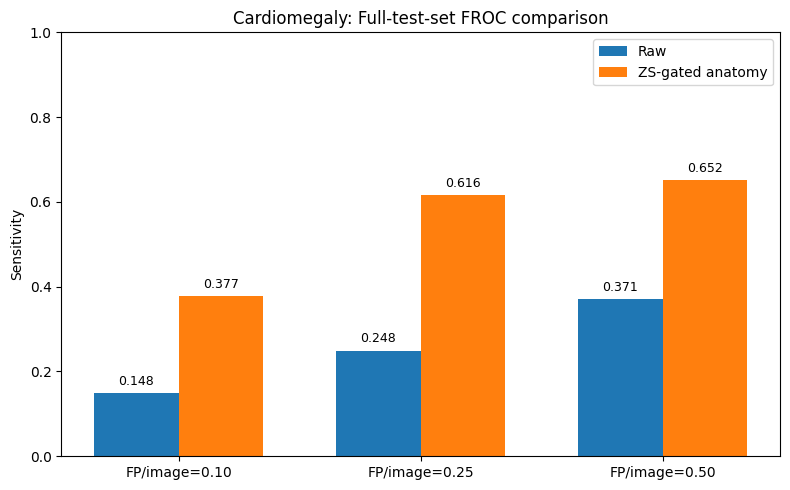

In [19]:
# ============================================================
# Quantitative visualization of final full-set results
# ============================================================

compare_csv = Path("/home/woody/iwi5/iwi5362h/ALBEF/results/clarity_end_to_end_zero_shot_gated/froc_comparison_fullset_cardiomegaly.csv")
out_dir = compare_csv.parent / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(compare_csv)
row = df.iloc[0]

fps = ["0.10", "0.25", "0.50"]
raw_vals = [row["sens@0.10_raw"], row["sens@0.25_raw"], row["sens@0.50_raw"]]
gated_vals = [row["sens@0.10_zs_gated"], row["sens@0.25_zs_gated"], row["sens@0.50_zs_gated"]]

x = np.arange(len(fps))
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - w/2, raw_vals, width=w, label="Raw")
plt.bar(x + w/2, gated_vals, width=w, label="ZS-gated anatomy")
plt.xticks(x, [f"FP/image={fp}" for fp in fps])
plt.ylabel("Sensitivity")
plt.ylim(0, 1.0)
plt.title("Cardiomegaly: Full-test-set FROC comparison")
plt.legend()

for i, v in enumerate(raw_vals):
    plt.text(i - w/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(gated_vals):
    plt.text(i + w/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / "cardiomegaly_froc_bar_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
compare.T

,0
label,Cardiomegaly
sens@0.10_raw,0.148387
sens@0.25_raw,0.248387
sens@0.50_raw,0.370968
num_gt_boxes_raw,310
num_preds_raw,19027
curve_csv_raw,/home/woody/iwi5/iwi5362h/ALBEF/results/clarit...
sens@0.10_zs_gated,0.377419
sens@0.25_zs_gated,0.616129
sens@0.50_zs_gated,0.651613


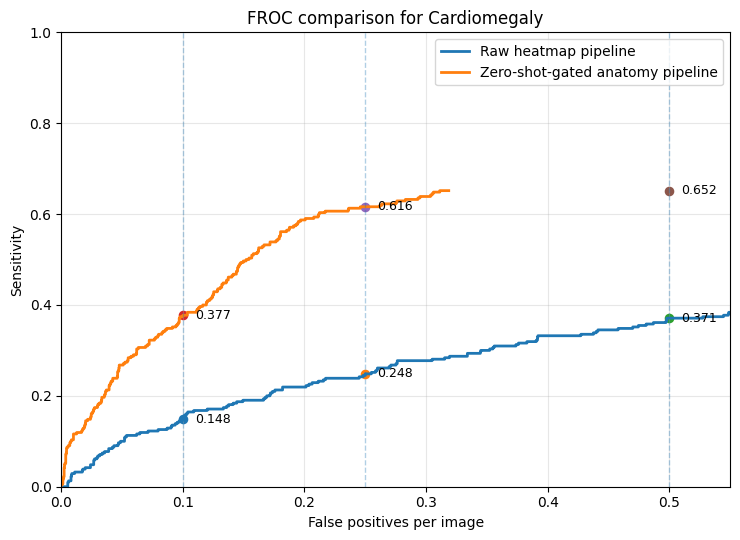

Saved plot to: /home/woody/iwi5/iwi5362h/ALBEF/results/clarity_end_to_end_zero_shot_gated/figures/cardiomegaly_froc_raw_vs_zs_gated_annotated.png


In [22]:
compare_csv = Path("/home/woody/iwi5/iwi5362h/ALBEF/results/clarity_end_to_end_zero_shot_gated/froc_comparison_fullset_cardiomegaly.csv")
out_dir = compare_csv.parent / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

compare_df = pd.read_csv(compare_csv)
row = compare_df.iloc[0]

raw_curve = pd.read_csv(Path(row["curve_csv_raw"]))
gated_curve = pd.read_csv(Path(row["curve_csv_zs_gated"]))

plt.figure(figsize=(7.5, 5.5))
plt.plot(raw_curve["fp_per_image"], raw_curve["sensitivity"], linewidth=2, label="Raw heatmap pipeline")
plt.plot(gated_curve["fp_per_image"], gated_curve["sensitivity"], linewidth=2, label="Zero-shot-gated anatomy pipeline")

for fp in [0.10, 0.25, 0.50]:
    plt.axvline(fp, linestyle="--", linewidth=1, alpha=0.35)

# annotate reported points
reported = {
    "Raw": {
        0.10: row["sens@0.10_raw"],
        0.25: row["sens@0.25_raw"],
        0.50: row["sens@0.50_raw"],
    },
    "Gated": {
        0.10: row["sens@0.10_zs_gated"],
        0.25: row["sens@0.25_zs_gated"],
        0.50: row["sens@0.50_zs_gated"],
    }
}

for fp, sens in reported["Raw"].items():
    plt.scatter([fp], [sens], s=35)
    plt.text(fp + 0.01, sens, f"{sens:.3f}", fontsize=9, va="center")

for fp, sens in reported["Gated"].items():
    plt.scatter([fp], [sens], s=35)
    plt.text(fp + 0.01, sens, f"{sens:.3f}", fontsize=9, va="center")

plt.xlim(0, 0.55)
plt.ylim(0, 1.0)
plt.xlabel("False positives per image")
plt.ylabel("Sensitivity")
plt.title("FROC comparison for Cardiomegaly")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = out_dir / "cardiomegaly_froc_raw_vs_zs_gated_annotated.png"
plt.savefig(save_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved plot to:", save_path)